In [1]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import matplotlib.patches as patches

# Jupyter Notebookで高解像度表示するための設定
%config InlineBackend.figure_format = 'retina'

# 論文向けスタイル設定
plt.rcParams['font.family'] = 'serif'     # 明朝/ローマン体系
plt.rcParams['mathtext.fontset'] = 'cm'   # 数式をLaTeX風に
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

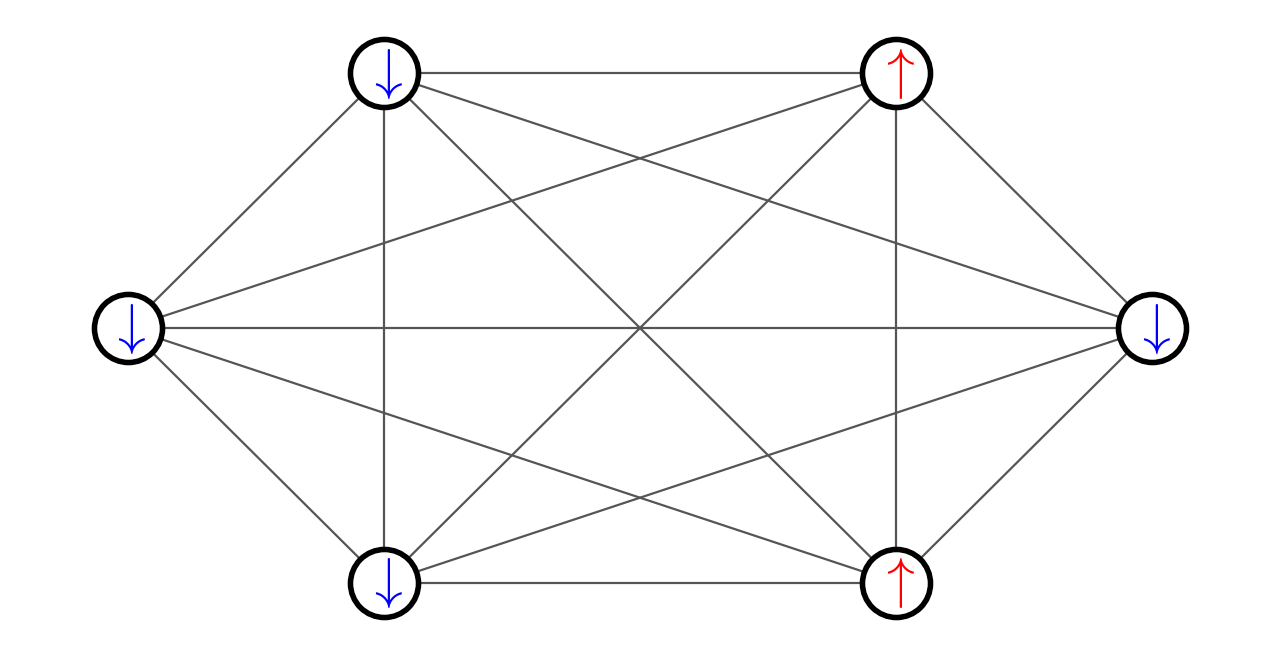

In [19]:
def draw_fig1_fully_connected():
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # ノード数（見やすさのため16個に限定）
    num_nodes = 6
    G = nx.complete_graph(num_nodes)
    pos = nx.circular_layout(G)
    
    # 1. 全結合エッジの描画（薄いグレーで密結合を表現）
    # 全員が全員と繋がっている＝距離の概念がないことを強調
    nx.draw_networkx_edges(
        G, pos, ax=ax, 
        width=0.8, alpha=1.0, edge_color='#555555'
    )
    
    # 2. ノード（スピン）の描画
    nx.draw_networkx_nodes(
        G, pos, ax=ax, 
        node_size=600, 
        node_color='white', 
        edgecolors='black', 
        linewidths=2.0
    )
    
    # 3. スピンの状態（上向き/下向き）をランダムに配置
    np.random.seed(42) # 再現性確保
    for i, (x, y) in pos.items():
        spin = np.random.choice([-1, 1])
        marker = r'$\uparrow$' if spin == 1 else r'$\downarrow$'
        color = 'red' if spin == 1 else 'blue'
        # 矢印を描画
        ax.text(x, y, marker, fontsize=20, ha='center', va='center', 
                color=color, fontweight='bold')

    ax.axis('off') # 軸を消す
    plt.show()

# 実行
draw_fig1_fully_connected()

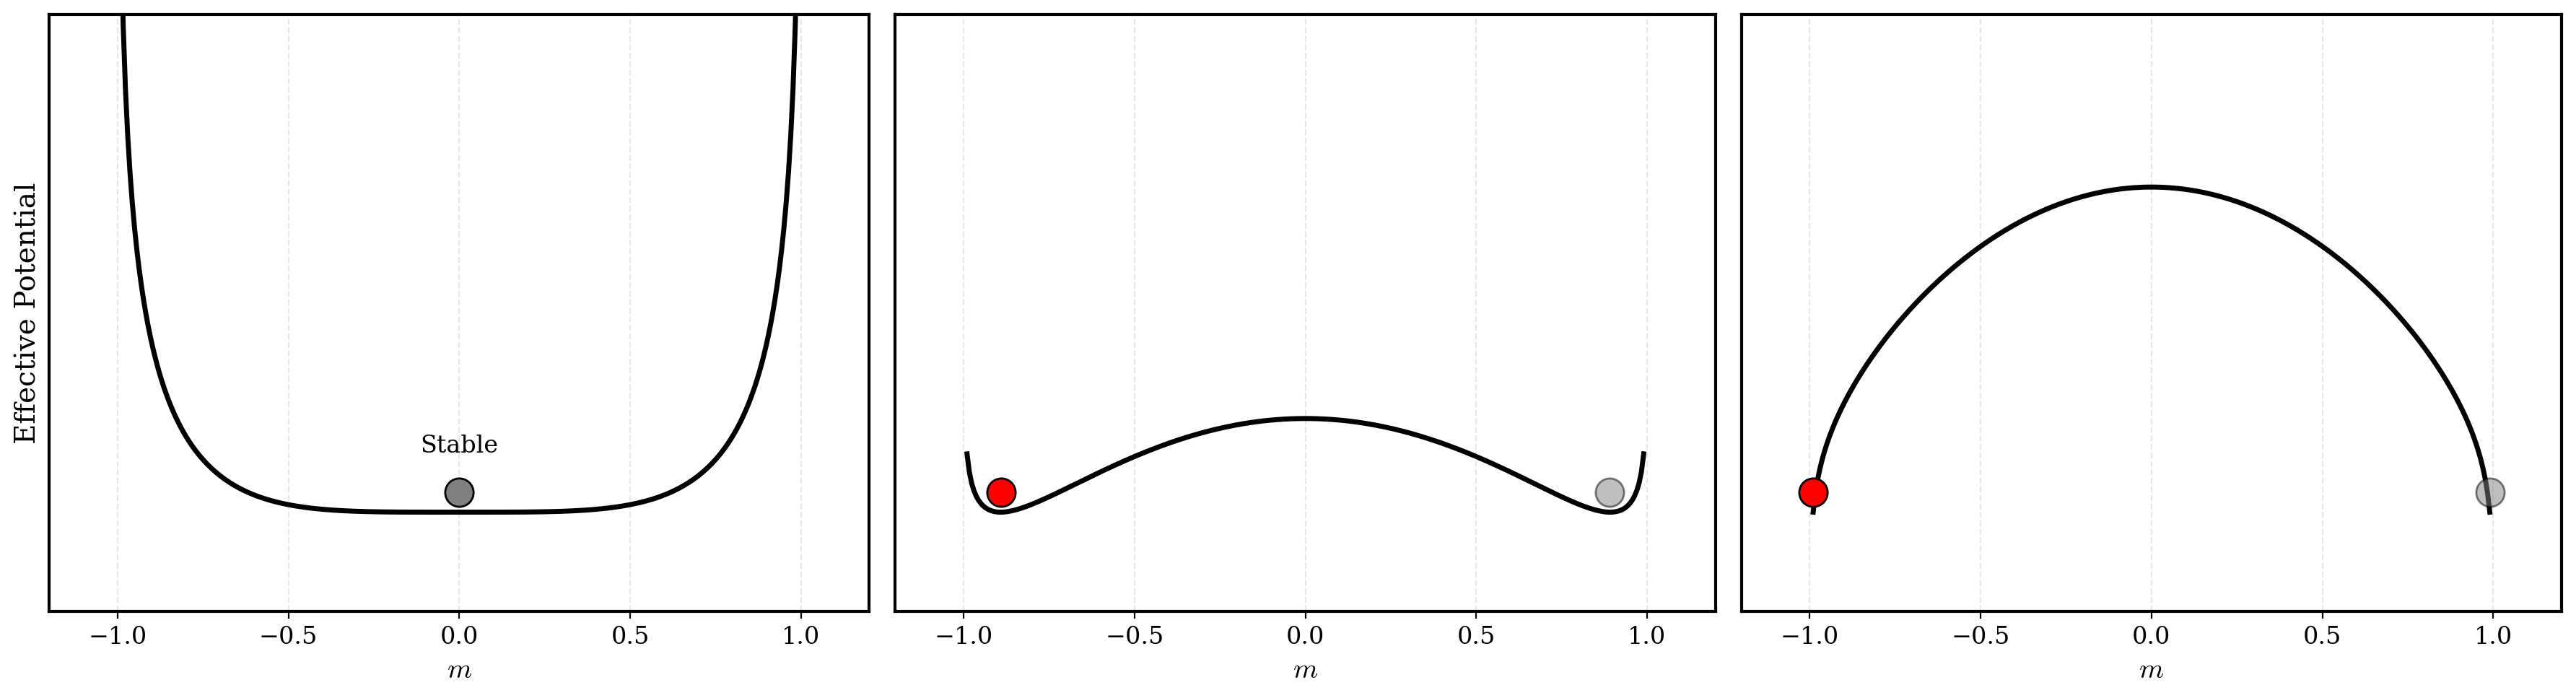

In [15]:
def draw_fig2_potential_landscape():
    # 磁化 m の範囲 (-1 to 1)
    m = np.linspace(-0.99, 0.99, 300)

    # 簡易自由エネルギー関数 F(m) 
    # F ~ -Entropy - alpha * Energy
    # Entropy項: (1/alpha - 1) * log(1-m^2)
    # Energy項: m^2
    def free_energy(m, alpha):
        term_entropy = - (1.0/alpha - 1.0) * np.log(1 - m**2)
        term_energy = - m**2 # 強磁性相互作用
        return term_entropy + term_energy

    # 3つのフェーズを描画
    alphas = [0.5, 0.83, 1.2] # 0.83付近が臨界点 alpha_c
    #titles = [
    #    r"Phase 1: Exploration ($\alpha < \alpha_c$)" + "\n" + r"Single Well (Random)",
    #    r"Phase 2: Transition ($\alpha \approx \alpha_c$)" + "\n" + r"Flat Bottom (Critical)",
    #    r"Phase 3: Exploitation ($\alpha > \alpha_c$)" + "\n" + r"Double Well (Magnetized)"
    #]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, alpha in zip(axes, alphas):
        y = free_energy(m, alpha)
        # プロットを見やすく正規化（最小値を0に合わせる）
        y = y - np.min(y)
        
        # ポテンシャル曲線の描画
        ax.plot(m, y, color='black', linewidth=2.5, label=f'$\\alpha={alpha}$')
        
        # ボール（現在の状態）の描画
        if alpha < 0.7:
            # 中央に安定
            ax.scatter([0], [0.1], s=200, c='gray', zorder=5, edgecolors='black')
            ax.text(0, 0.3, "Stable", ha='center')
        else:
            # 左右に分裂（自発的対称性の破れ）
            min_idx = np.argmin(y)
            m_min = m[min_idx]
            # 両方の谷にボールを描く（どちらかに落ちる）
            ax.scatter([m_min], [0.1], s=200, c='red', zorder=5, edgecolors='black', label='Solution')
            ax.scatter([-m_min], [0.1], s=200, c='gray', zorder=5, edgecolors='black', alpha=0.5)
            
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-0.5, 2.5)
        ax.set_xlabel(r"$m$", fontsize=14)
        if alpha == 0.5:
            ax.set_ylabel("Effective Potential", fontsize=14)
        ax.set_yticks([]) # Y軸の数値は相対的なので消す
        #ax.set_title(title, fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

# 実行
draw_fig2_potential_landscape()

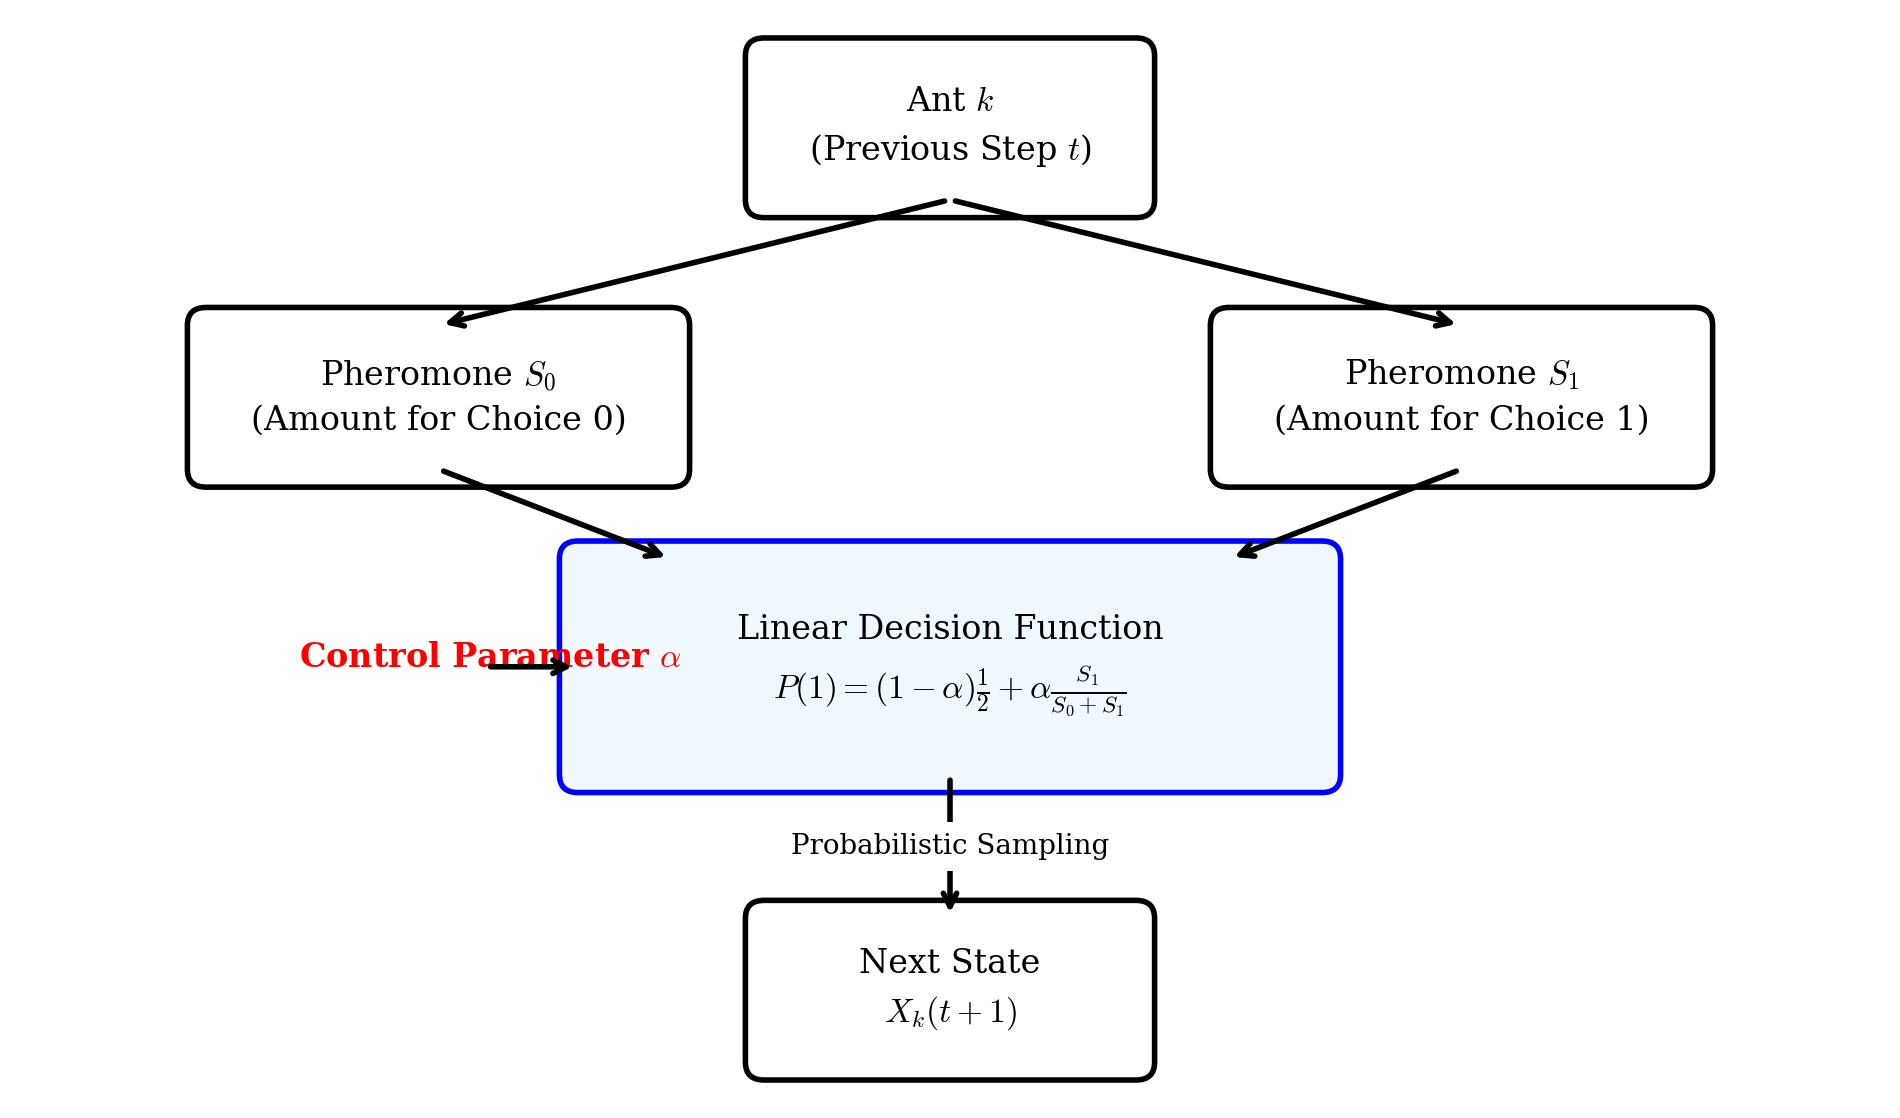

In [17]:
def draw_fig3_decision_flow():
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis('off')

    # ボックスを描画する関数
    def create_box(x, y, width, height, text, color='white', edge='black', style='round,pad=0.1'):
        box = patches.FancyBboxPatch(
            (x, y), width, height,
            boxstyle=style, linewidth=2, edgecolor=edge, facecolor=color
        )
        ax.add_patch(box)
        ax.text(x + width/2, y + height/2, text, ha='center', va='center', fontsize=12, linespacing=1.5)
        return {'x': x + width/2, 'y': y, 'top': y + height}

    # 矢印を描画する関数
    def create_arrow(x1, y1, x2, y2, label=None):
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", lw=2, color='black'))
        if label:
            ax.text((x1+x2)/2, (y1+y2)/2, label, ha='center', va='center', 
                    backgroundcolor='white', fontsize=10, bbox=dict(facecolor='white', edgecolor='none'))

    # --- フローチャートの要素配置 ---

    # 1. アリ（主体）
    pos_ant = create_box(4.0, 5.0, 2.0, 0.8, "Ant $k$\n(Previous Step $t$)")

    # 2. フェロモン情報（入力）
    pos_s0 = create_box(1.0, 3.5, 2.5, 0.8, "Pheromone $S_0$\n(Amount for Choice 0)")
    pos_s1 = create_box(6.5, 3.5, 2.5, 0.8, "Pheromone $S_1$\n(Amount for Choice 1)")

    # 3. 決定関数（コアアルゴリズム）
    # 論文の線形関数式をここに記載
    formula = r"Linear Decision Function" + "\n" + \
              r"$P(1) = (1-\alpha)\frac{1}{2} + \alpha \frac{S_1}{S_0+S_1}$"
    pos_func = create_box(3.0, 1.8, 4.0, 1.2, formula, color='#f0f8ff', edge='blue')

    # 4. パラメータ入力
    ax.text(1.5, 2.4, r"Control Parameter $\alpha$", fontsize=12, fontweight='bold', color='red')
    create_arrow(2.5, 2.4, 3.0, 2.4) # αから関数への矢印

    # 5. 次の状態（出力）
    pos_next = create_box(4.0, 0.2, 2.0, 0.8, "Next State\n$X_k(t+1)$")

    # --- 接続 ---
    # Ant -> Pheromones
    create_arrow(pos_ant['x'], pos_ant['y'], pos_s0['x'], pos_s0['top'])
    create_arrow(pos_ant['x'], pos_ant['y'], pos_s1['x'], pos_s1['top'])

    # Pheromones -> Function
    create_arrow(pos_s0['x'], pos_s0['y'], pos_func['x'] - 1.5, pos_func['top'])
    create_arrow(pos_s1['x'], pos_s1['y'], pos_func['x'] + 1.5, pos_func['top'])

    # Function -> Next State
    create_arrow(pos_func['x'], pos_func['y'], pos_next['x'], pos_next['top'], label="Probabilistic Sampling")

    plt.show()

# 実行
draw_fig3_decision_flow()

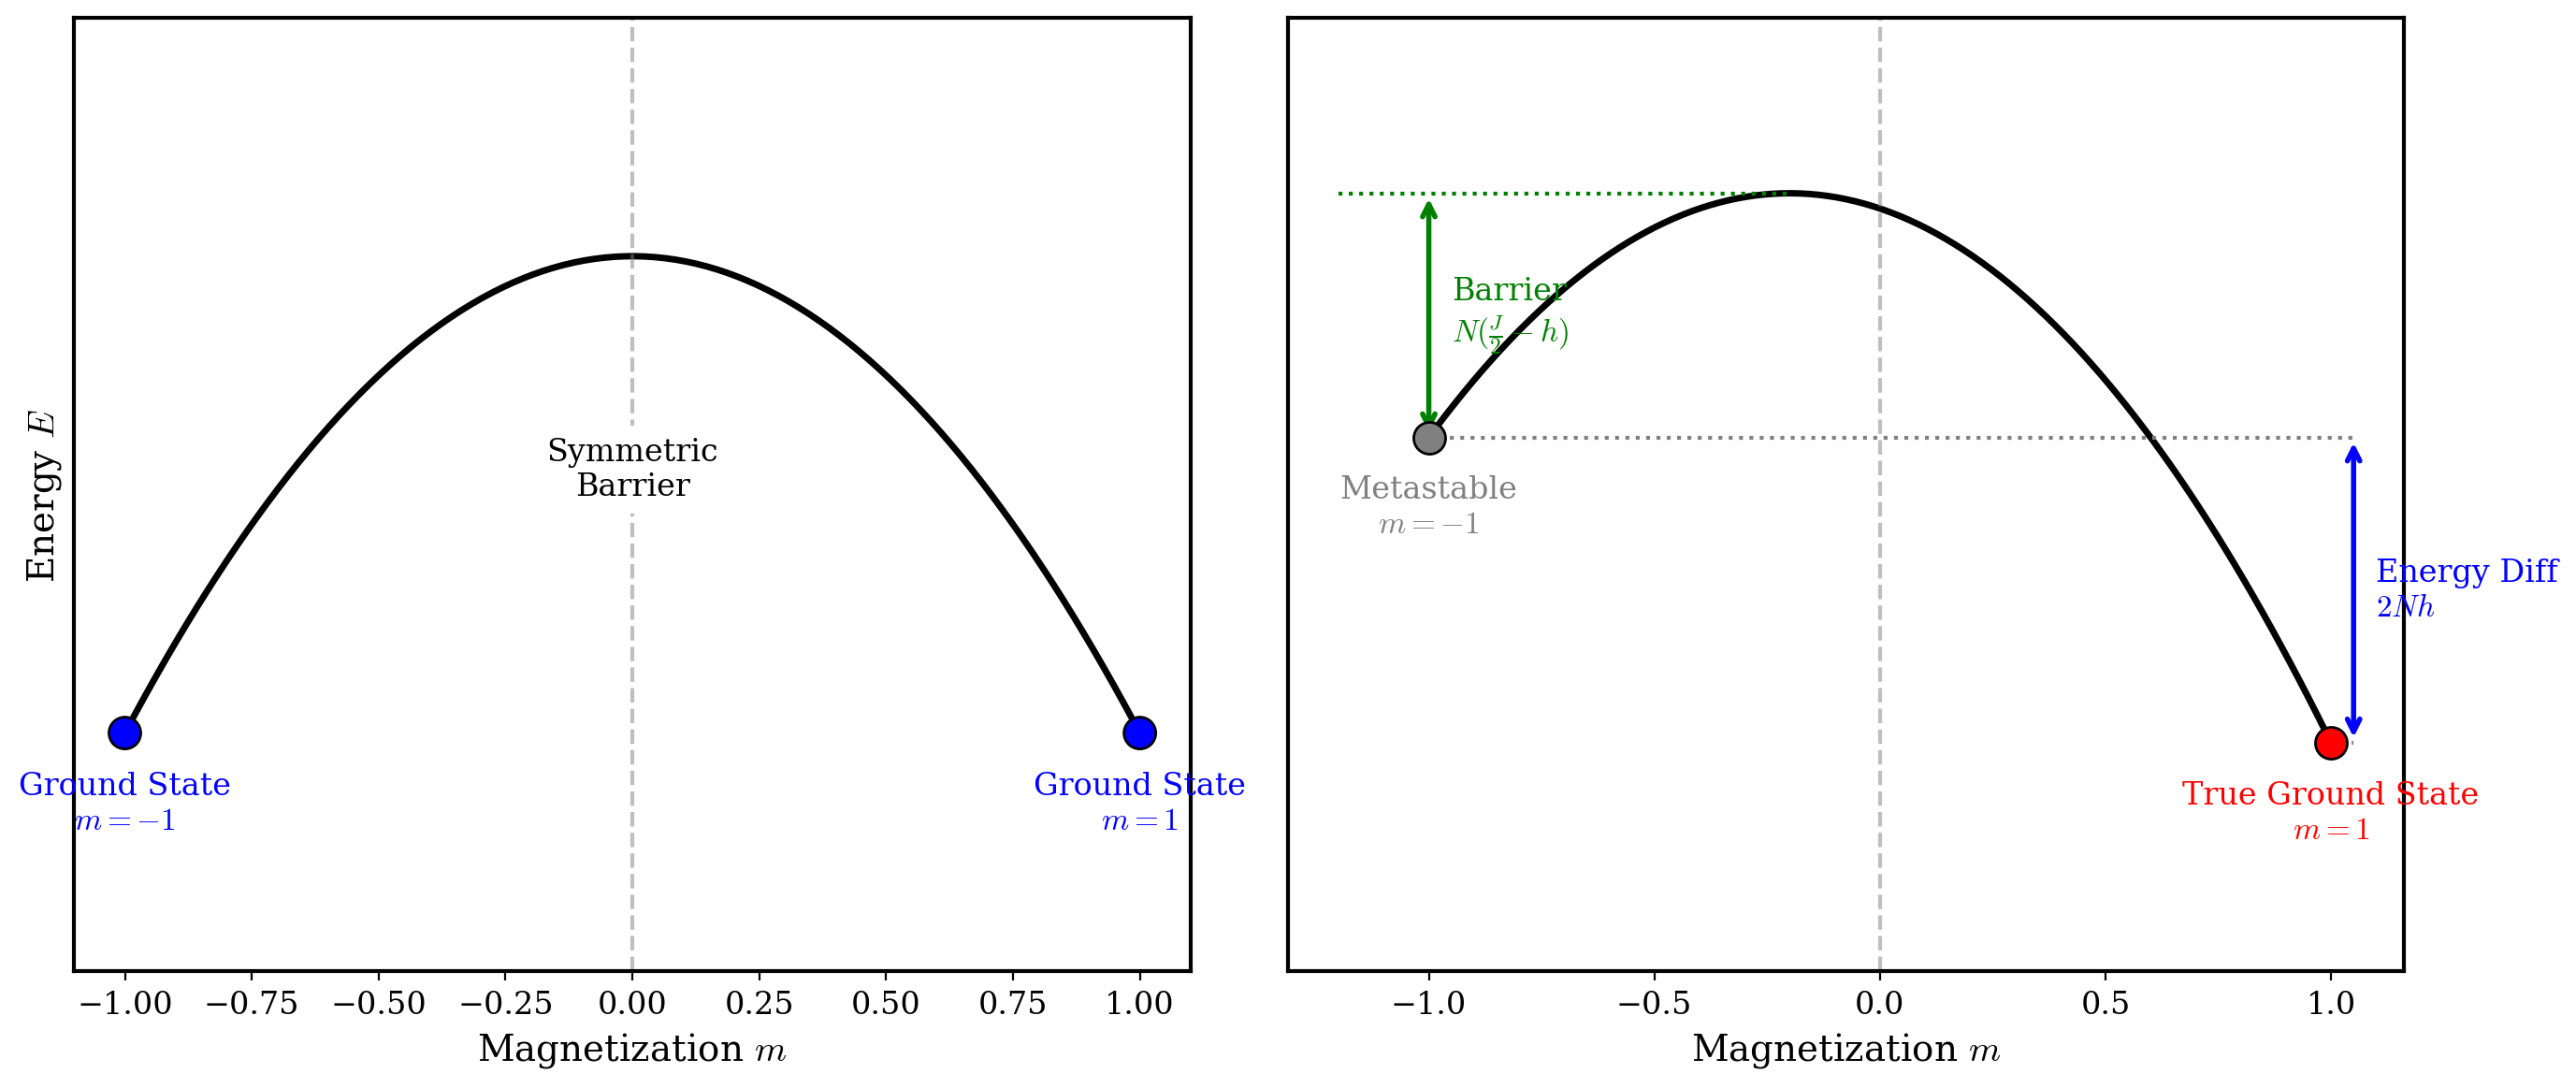

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Jupyter Notebook設定
%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 12

def draw_energy_landscape():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 磁化 m の範囲
    m = np.linspace(-1, 1, 200)
    N = 1 # スケーリング用（図示なので1でOK）
    J = 2.0 # 相互作用強度
    
    # --- 左図：h=0 (対称・縮退) ---
    h0 = 0
    # エネルギー式: E ~ -N(hm + J/2 * m^2)  (定数項は無視して形状のみ)
    E0 = -N * (h0 * m + (J / 2) * m**2)
    
    ax0 = axes[0]
    ax0.plot(m, E0, color='black', linewidth=2.5)
    ax0.set_xlabel(r"Magnetization $m$", fontsize=14)
    ax0.set_ylabel(r"Energy $E$", fontsize=14)
    ax0.set_ylim(-1.5, 0.5)
    ax0.set_yticks([]) # 相対値なので数値は消す
    ax0.axvline(0, color='gray', linestyle='--', alpha=0.5)
    
    # 基底状態のマーカー
    ax0.scatter([-1, 1], [E0[0], E0[-1]], s=150, c=['blue', 'blue'], zorder=5, edgecolors='black')
    ax0.text(-1, E0[0]-0.2, "Ground State\n$m=-1$", ha='center', color='blue')
    ax0.text(1, E0[-1]-0.2, "Ground State\n$m=1$", ha='center', color='blue')
    ax0.text(0, -0.5, "Symmetric\nBarrier", ha='center', fontsize=12, backgroundcolor='white')

    # --- 右図：h>0 (対称性の破れ・障壁) ---
    h1 = 0.4 # 外部磁場
    E1 = -N * (h1 * m + (J / 2) * m**2)
    
    ax1 = axes[1]
    ax1.plot(m, E1, color='black', linewidth=2.5)
    ax1.set_xlabel(r"Magnetization $m$", fontsize=14)
    ax1.set_yticks([])
    ax1.set_ylim(-2.0, 0.5)
    ax1.axvline(0, color='gray', linestyle='--', alpha=0.5)

    # 状態マーカー
    # m=-1 (Local Min), m=1 (Global Min)
    e_left = E1[0]  # m=-1
    e_right = E1[-1] # m=1
    e_peak = np.max(E1) # Barrier top roughly at m = -h/J
    m_peak = m[np.argmax(E1)]

    ax1.scatter([-1], [e_left], s=150, c='gray', zorder=5, edgecolors='black', label='Metastable')
    ax1.scatter([1], [e_right], s=150, c='red', zorder=5, edgecolors='black', label='Ground State')

    # エネルギー差 2Nh の矢印
    ax1.annotate(
        "", xy=(1.05, e_left), xytext=(1.05, e_right),
        arrowprops=dict(arrowstyle="<->", color='blue', lw=2)
    )
    ax1.text(1.1, (e_left + e_right)/2, r"Energy Diff" + "\n" + r"$2Nh$", 
             ha='left', va='center', color='blue', fontsize=12)
    # 点線を引いて高さをわかりやすく
    ax1.hlines(e_left, -1, 1.05, linestyles=':', colors='gray')
    ax1.hlines(e_right, 1, 1.05, linestyles=':', colors='gray')

    # エネルギー障壁 N(J/2 - h) の矢印
    # m=-1 から Peak までの高さ
    ax1.annotate(
        "", xy=(-1.0, e_peak), xytext=(-1.0, e_left),
        arrowprops=dict(arrowstyle="<->", color='green', lw=2)
    )
    ax1.text(-0.95, (e_peak + e_left)/2, r"Barrier" + "\n" + r"$N(\frac{J}{2} - h)$", 
             ha='left', va='center', color='green', fontsize=12)
    ax1.hlines(e_peak, -1.2, m_peak, linestyles=':', colors='green')

    # ラベル
    ax1.text(-1, e_left-0.25, "Metastable\n$m=-1$", ha='center', color='gray')
    ax1.text(1, e_right-0.25, "True Ground State\n$m=1$", ha='center', color='red')

    plt.tight_layout()
    plt.show()

draw_energy_landscape()